In [10]:
from Class_HydroData import HydroData
from Class_OnlineSensorBased import OnlineSensorBased
from Class_LabExperimentBased import LabExperimentBased

In [24]:
# Define necessary paths and variables to start

# path_to_data = '/home/saba/Desktop/GitHub_personal/wwdata/wwdata/2013/'
# path_to_store_db = '/home/saba/Desktop/GitHub_personal/wwdata/wwdata/2013/'
# file_names = ['raw_data_2013_01.txt','raw_data_2013_02.txt','raw_data_2013_03.txt','raw_data_2013_04.txt','raw_data_2013_05.txt','raw_data_2013_06.txt', \
# 'raw_data_2013_07.txt','raw_data_2013_08.txt','raw_data_2013_09.txt','raw_data_2013_10.txt','raw_data_2013_11.txt','raw_data_2013_12.txt']

# variable_names = {'Q' : 'Totaal debiet influent. waarde T.B.V BBS (F_CV)',\
#                     'COD' : 'CZVtot. Ontvangskelder 1 CZV Totaal (F_CV)', \
#                     'sCOD' : 'CZVnf. Ontvangskelder 1  CVZ Opgelost (F_CV)', \
#                     'TSS' : 'TSS. Ontvangskelder 1 Zwevendestof (F_CV)', \
#                     'NH4' : 'Ammoniummeting influentgemaal (F_CV)',\
#                     'PO4' : 'Fosfaat.menggoot. meetwaarde (F_CV)'}
                    
# typical_dry_data = {'initial_day': [2013, 7, 4], 'duration': 17}
# path_to_inf_model = '/home/saba/Desktop/GitHub_personal/wwdata/wwdata/2013/2013_InfluentModel_tot_v2016.txt'
# influent_file_name = 'influent_test_.txt'

In [11]:
import pandas as pd
import numpy as np

def make_test_dataframe(n: int = 48, freq: str = "h", seed: int = 42, start=pd.Timestamp("2025-01-01 00:00")) -> pd.DataFrame:
    """
    Create a synthetic sensor dataset for testing HydroData and DataProcessor methods.

    Parameters
    ----------
    n : int, default 48
        Number of time points.
    freq : str, default 'H'
        Frequency string for the DatetimeIndex (e.g., 'H', '15min').
    seed : int, default 42
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        A test DataFrame with columns ["flow", "level", "rain"] and a DatetimeIndex.
        Includes some NaNs, a duplicate timestamp, and an intentional gap.
    """
    rng = np.random.default_rng(seed)
    start = start
    idx = pd.date_range(start=start, periods=n, freq=freq)

    # Add a duplicate timestamp
    idx = idx.insert(10, idx[10])

    # Drop one index to create a gap
    idx = idx.delete(20)

    df = pd.DataFrame(
        {
            "flow": rng.normal(loc=100, scale=10, size=len(idx)),
            "level": rng.normal(loc=5, scale=0.5, size=len(idx)),
            "rain": rng.poisson(lam=0.2, size=len(idx)).astype(float),
        },
        index=idx,
    )

    # Introduce some NaNs
    df.iloc[5, 0] = np.nan  # missing flow
    df.iloc[15, 1] = np.nan  # missing level
    df.iloc[25, 2] = np.nan  # missing rain

    df.index.name = "Datetime"
    return df


In [12]:
df = make_test_dataframe(n=1000)
df.head()

,flow,level,rain
Datetime,,,
2025-01-01 00:00:00,103.047171,4.970359,0.0
2025-01-01 01:00:00,89.600159,4.635357,0.0
2025-01-01 02:00:00,107.504512,4.792763,0.0
2025-01-01 03:00:00,109.405647,5.316955,0.0
2025-01-01 04:00:00,80.489648,5.001497,0.0


In [27]:
h = HydroData(df)
h.data.head()

,flow,level,rain
Datetime,,,
2025-01-01 00:00:00,103.047171,4.970359,0.0
2025-01-01 01:00:00,89.600159,4.635357,0.0
2025-01-01 02:00:00,107.504512,4.792763,0.0
2025-01-01 03:00:00,109.405647,5.316955,0.0
2025-01-01 04:00:00,80.489648,5.001497,0.0


In [28]:
h.fill_index((df.index.min(), df.index.max()))

/tmp/ipykernel_78987/3675254910.py:1: RuntimeWarning: fill_index assumes equidistant sampling and inserts missing index values accordingly.
  h.fill_index((df.index.min(), df.index.max()))


In [29]:
h.drop_index_duplicates()

0 rows of duplicate indices have been dropped.


In [30]:
h.absolute_to_relative()

In [31]:
h.head()

,flow,level,rain,time_abs
time_rel,,,,
0.00000,103.047171,4.970359,0.0,2025-01-01 00:00:00
0.04167,89.600159,4.635357,0.0,2025-01-01 01:00:00
0.08333,107.504512,4.792763,0.0,2025-01-01 02:00:00
0.12500,109.405647,5.316955,0.0,2025-01-01 03:00:00
0.16667,80.489648,5.001497,0.0,2025-01-01 04:00:00


In [32]:
h.write('test', '/home/saba/Desktop/')

PosixPath('/home/saba/Desktop/test.csv')

In [33]:
h.get_avg()

flow     99.715760
level     4.959018
rain      0.201403
dtype: float64

In [34]:
h.get_std()

flow     9.890573
level    0.506987
rain     0.437140
dtype: float64

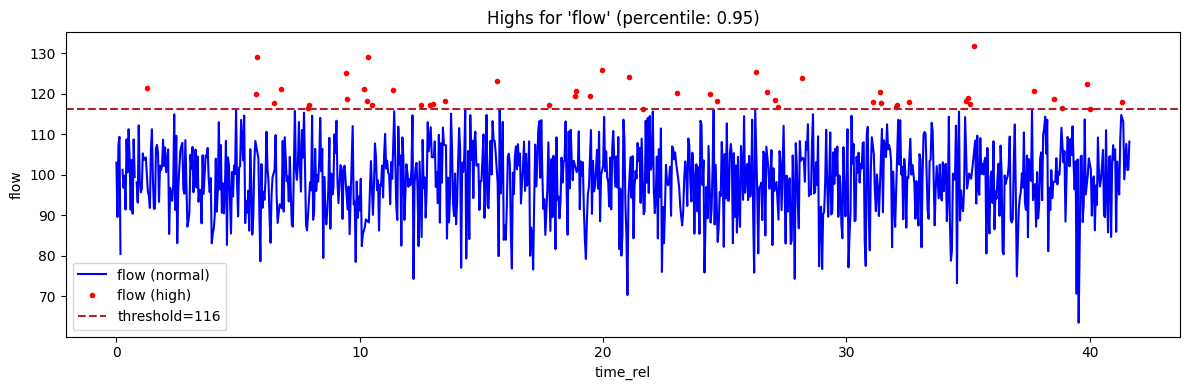

In [35]:
h.get_highs('flow', bound_value=0.95, plot=True)

In [36]:
h.get_summary()

{'numeric':                       flow       level        rain
 count           998.000000  998.000000  998.000000
 mean             99.715760    4.959018    0.201403
 std               9.890573    0.506987    0.437140
 min              63.515872    3.476184    0.000000
 25%              93.046665    4.635248    0.000000
 50%             100.061779    4.978108    0.000000
 75%             105.889750    5.300788    0.000000
 max             131.788537    6.457122    2.000000
 missing_count     2.000000    2.000000    2.000000
 missing_pct       0.200000    0.200000    0.200000
 filtered_count    0.000000    0.000000    0.000000
 filtered_pct      0.000000    0.000000    0.000000,
 'non_numeric':           count  missing_count  missing_pct
 time_abs   1000              0          0.0,
 'index':    n_rows  start     end median_freq
 0    1000    0.0  41.625         NaT}

In [37]:
h.missing_stats()

,total,missing,missing_pct,filtered,filtered_pct,effective_missing,effective_missing_pct
flow,1000,2,0.2,0,0.0,2,0.2
level,1000,2,0.2,0,0.0,2,0.2
rain,1000,2,0.2,0,0.0,2,0.2
time_abs,1000,0,0.0,0,0.0,0,0.0


In [38]:
h.gap_lengths()

,n_gaps,max_gap,mean_gap,total_missing,coverage_pct
column,,,,,
flow,2,1,1.0,2,99.8
level,2,1,1.0,2,99.8
rain,2,1,1.0,2,99.8
time_abs,0,0,0.0,0,100.0


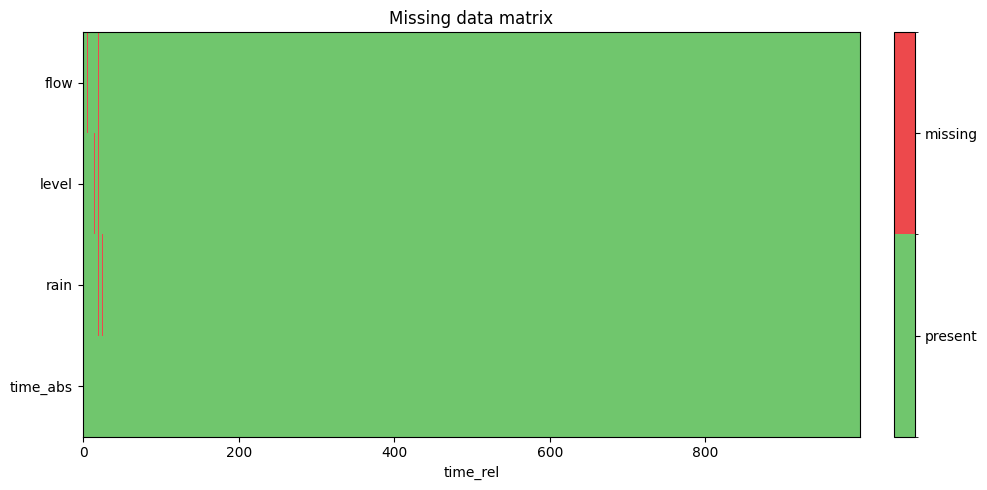

In [39]:
h.plot_missing_matrix()

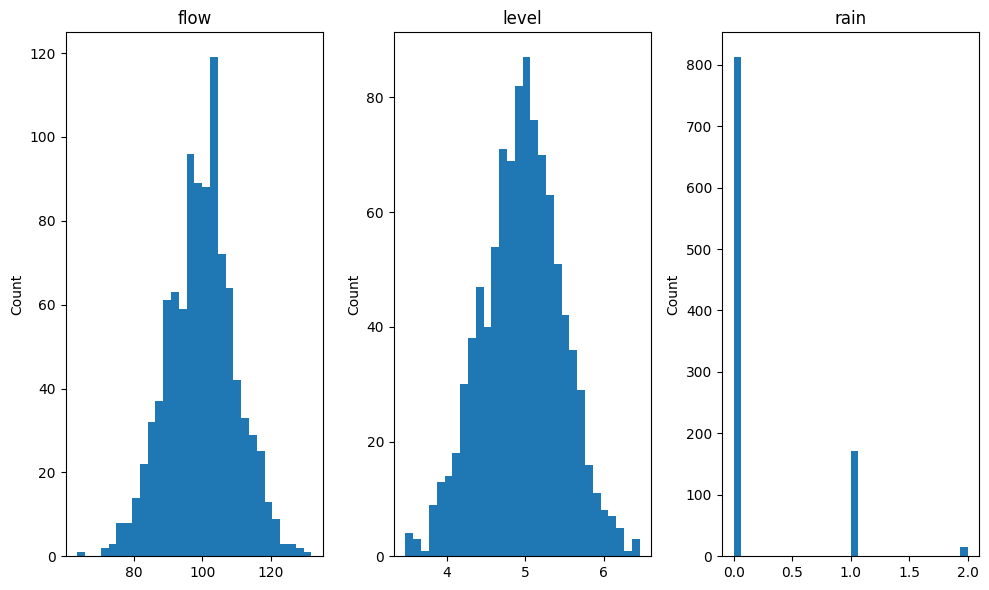

In [40]:
h.plot_histogram()

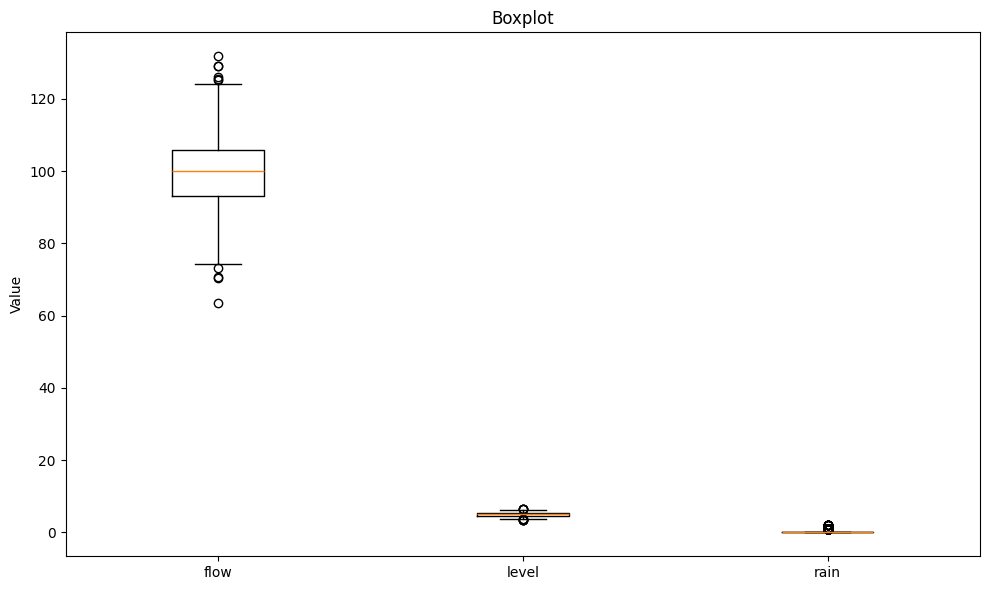

In [41]:
h.plot_boxplot()

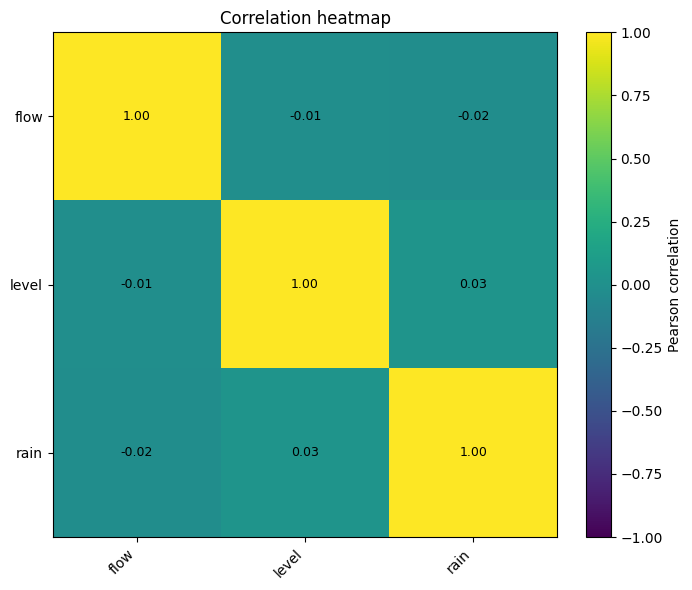

,flow,level,rain
flow,1.000000,-0.009391,-0.016059
level,-0.009391,1.000000,0.031823
rain,-0.016059,0.031823,1.000000


In [42]:
h.correlation_matrix(plot_heatmap=True)

In [43]:
h.tag_nan('flow')

2 values detected and tagged as filtered by function NaN tagging


8 values detected and tagged as filtered by function double value tagging


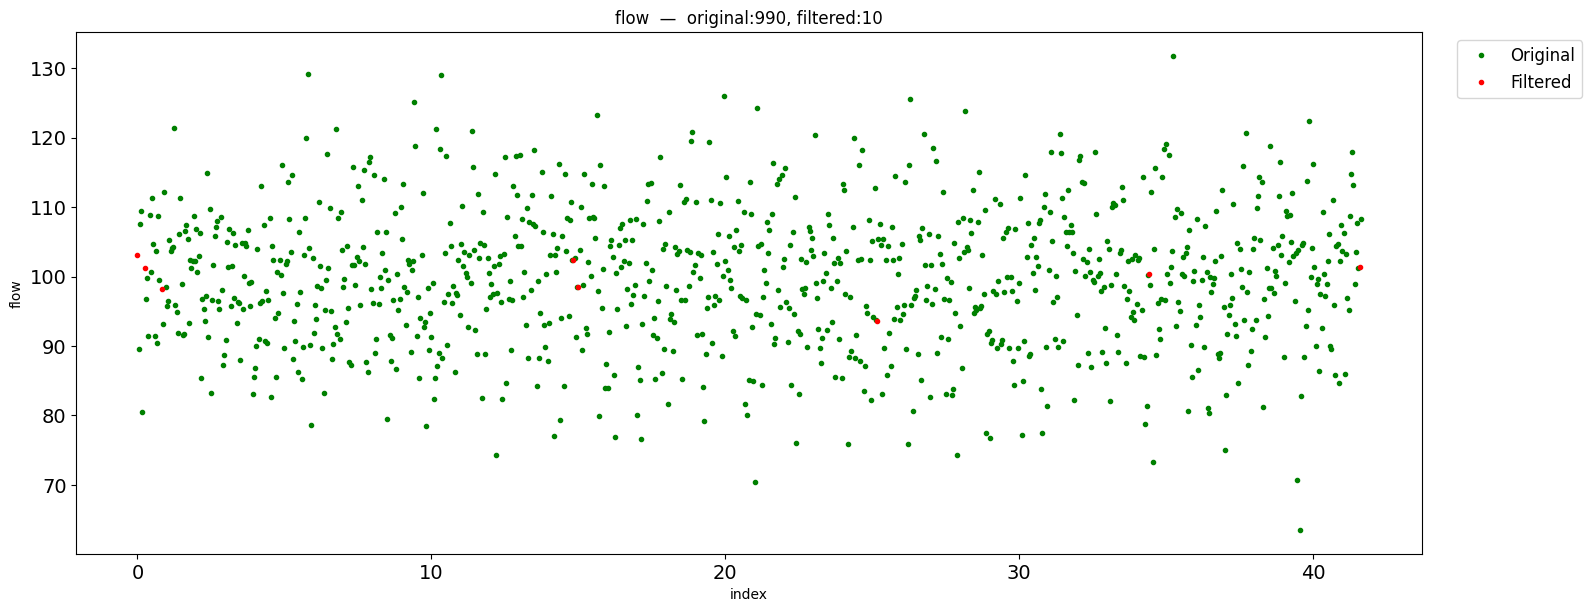

In [44]:
h.tag_doubles('flow', bound=0.1, plot=True)

24 values detected and tagged as filtered by function tagging of extremes (below)


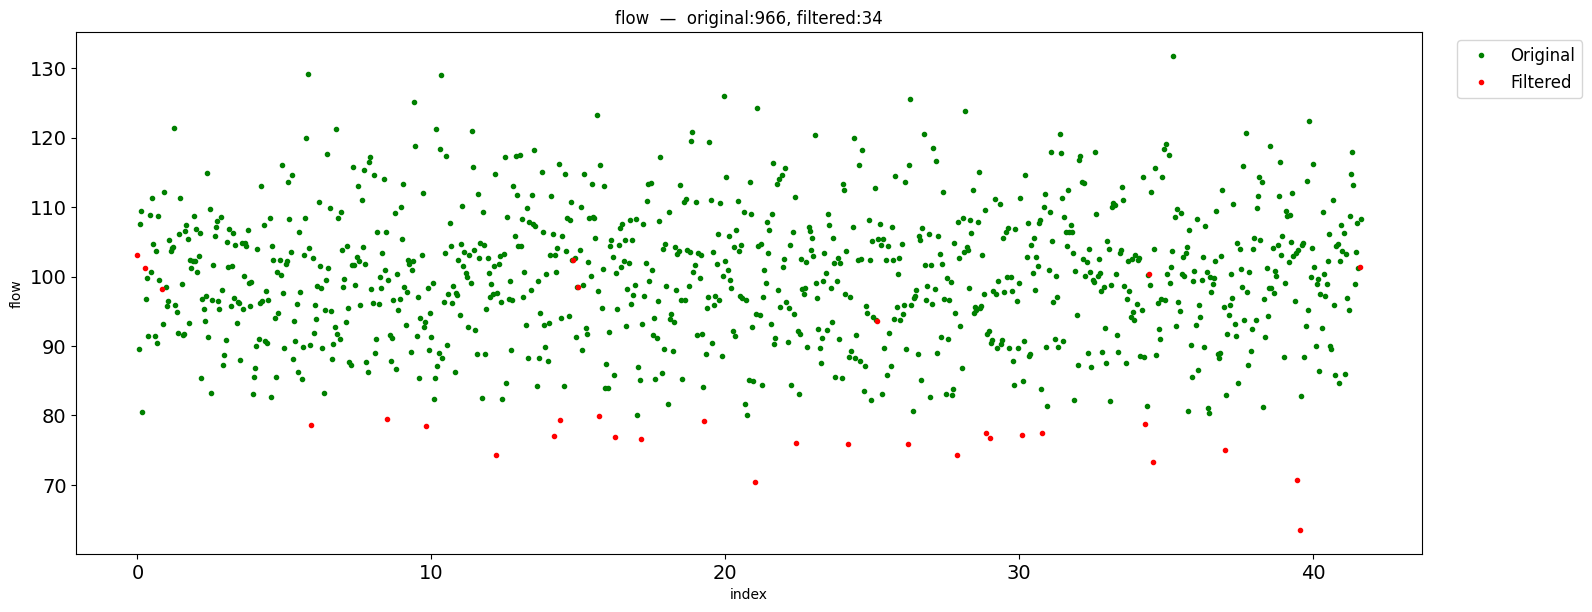

In [45]:
h.tag_extremes('flow', limit=80, method='below', plot=True)

970 values detected and tagged as filtered by function moving slope filter (window=1)


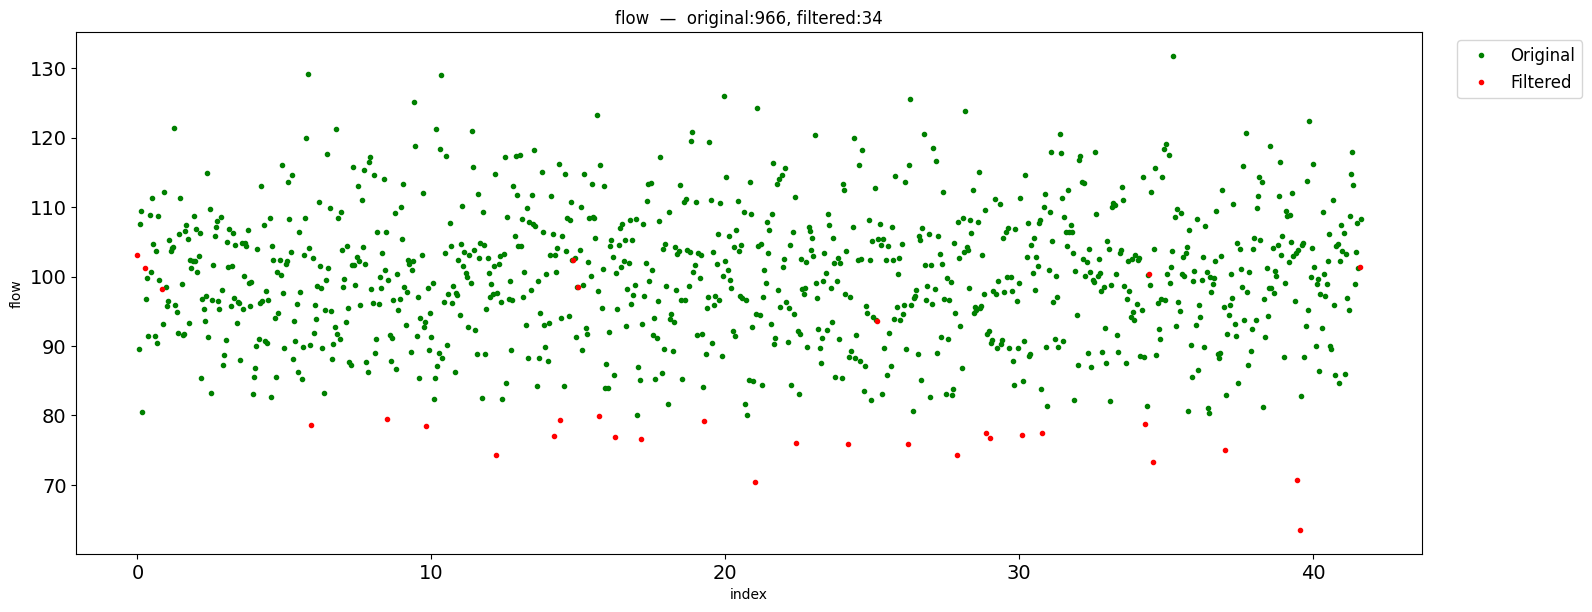

In [46]:
h.moving_slope_filter('flow', time_unit='min', cutoff=10, plot=True)

In [47]:
h.isolation_forest_filter(['flow', 'level'], plot=True)

10 values detected and tagged as filtered by function IsolationForest (contamination=0.01)


In [48]:
h.calc_daily_profile('flow', arange=(0,2), clear=True, plot=True)

TypeError: calc_daily_profile requires a DatetimeIndex.

In [13]:
df = make_test_dataframe(n=1000)
s = OnlineSensorBased(df)
s.data.head()

,flow,level,rain
Datetime,,,
2025-01-01 00:00:00,103.047171,4.970359,0.0
2025-01-01 01:00:00,89.600159,4.635357,0.0
2025-01-01 02:00:00,107.504512,4.792763,0.0
2025-01-01 03:00:00,109.405647,5.316955,0.0
2025-01-01 04:00:00,80.489648,5.001497,0.0


In [14]:
s.fill_index((df.index.min(), df.index.max()))

/tmp/ipykernel_17891/1692953057.py:1: RuntimeWarning: fill_index assumes equidistant sampling and inserts missing index values accordingly.
  s.fill_index((df.index.min(), df.index.max()))


In [15]:
s.drop_index_duplicates()

0 rows have been dropped as duplicates.


(<Figure size 1600x600 with 1 Axes>, <Axes: xlabel='Time', ylabel='flow'>)

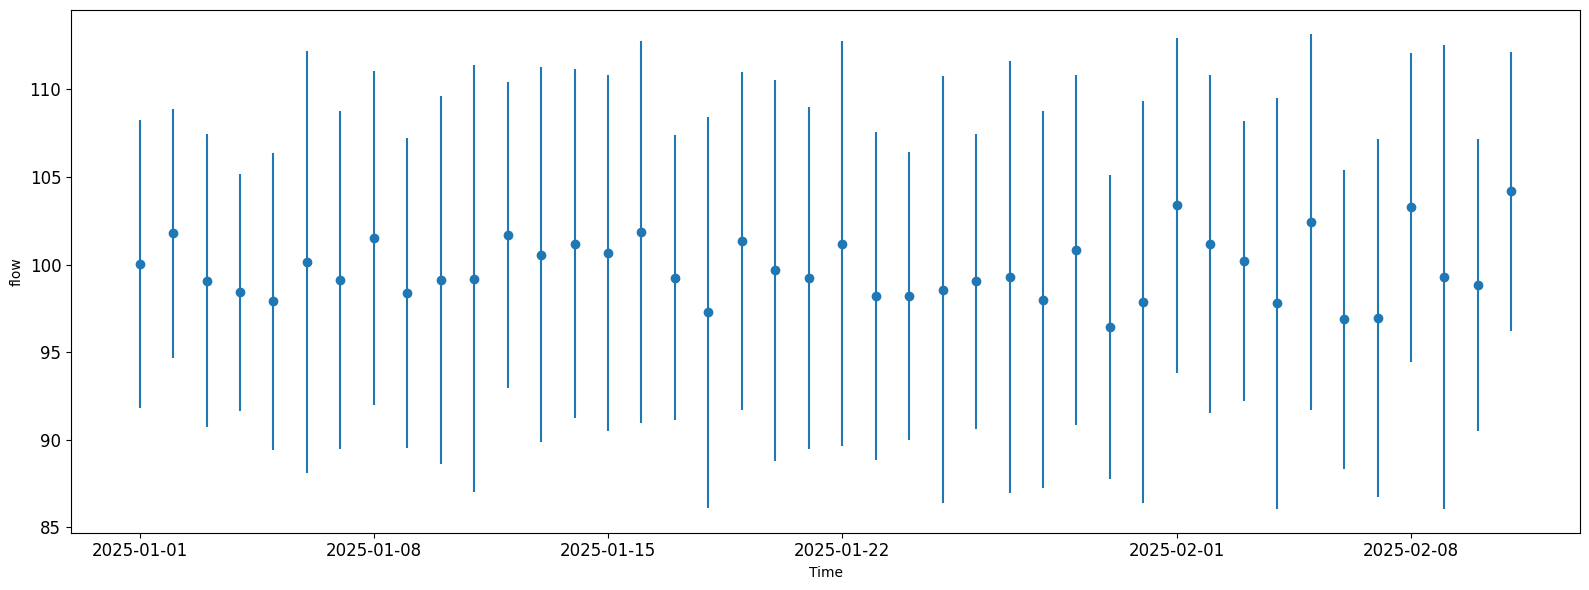

In [ ]:
s.calc_daily_average('flow', plot=True)

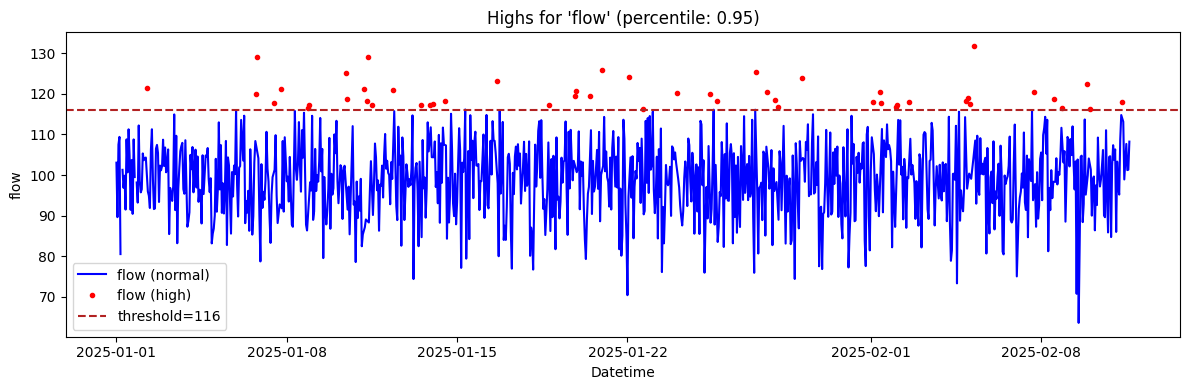

In [6]:
s.get_highs('flow', bound_value=0.95, plot=True)

In [7]:
s.tag_nan('flow')

2 values detected and tagged as filtered by function NaN tagging


24 values detected and tagged as filtered by function tagging of extremes (below)


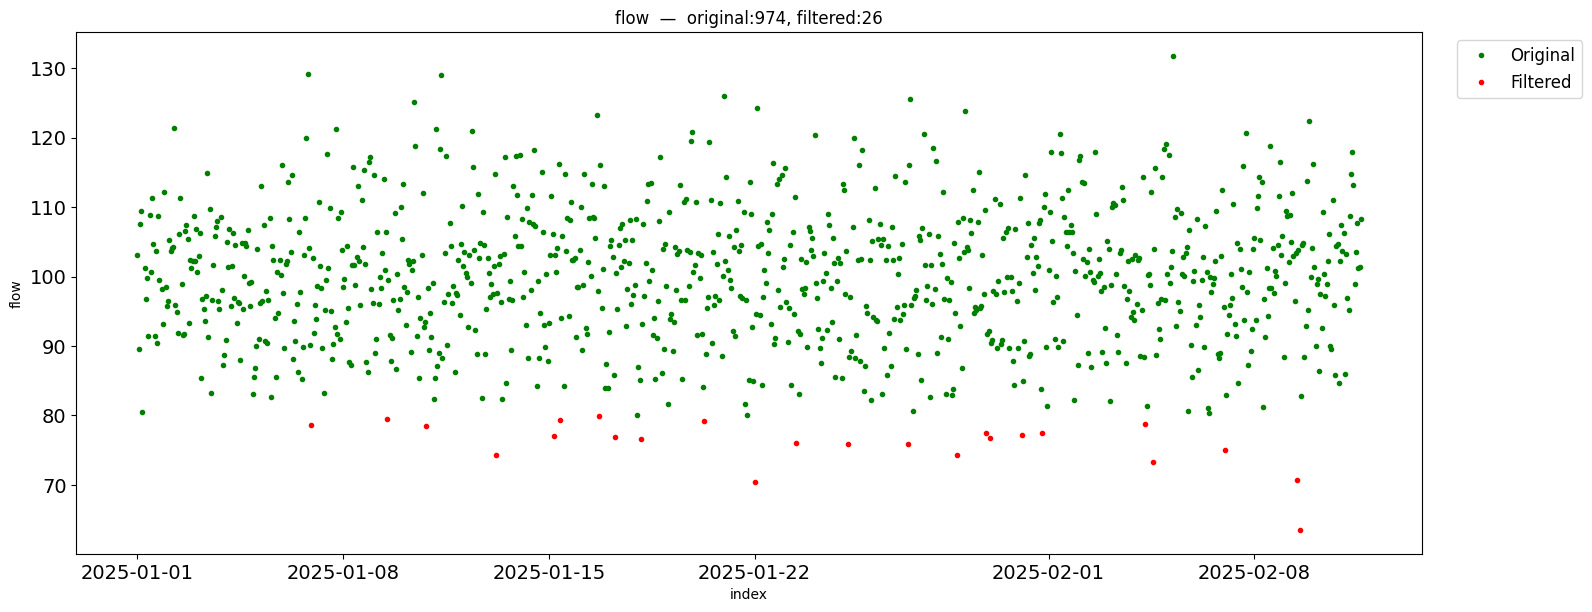

In [8]:
s.tag_extremes('flow', limit=80, method='below', plot=True)

7 values detected and tagged as filtered by function moving average filter (kind=mean)


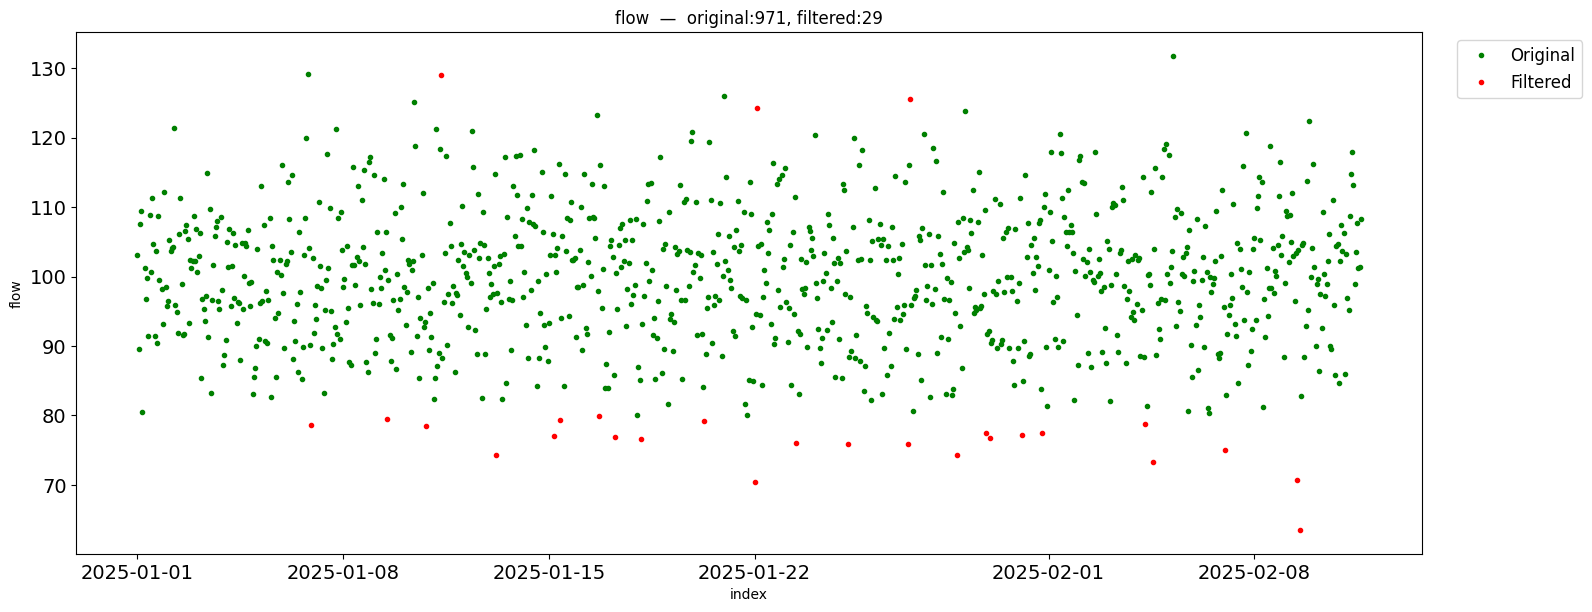

In [9]:
s.moving_average_filter('flow', window=7, cutoff_frac=0.25, plot=True)

In [ ]:
s.meta_valid[s.meta_valid['flow'] == 'filtered'].count()

flow    29
dtype: int64

In [ ]:
s.isolation_forest_filter(['flow', 'level'], plot=False)

10 values detected and tagged as filtered by function IsolationForest (contamination=0.01)


DatetimeIndex(['2025-01-01 05:00:00', '2025-01-01 19:00:00',
               '2025-01-06 22:00:00', '2025-01-09 12:00:00',
               '2025-01-10 20:00:00', '2025-01-11 08:00:00',
               '2025-01-13 05:00:00', '2025-01-15 04:00:00',
               '2025-01-15 09:00:00', '2025-01-16 17:00:00',
               '2025-01-17 06:00:00', '2025-01-18 03:00:00',
               '2025-01-20 07:00:00', '2025-01-22 00:00:00',
               '2025-01-22 02:00:00', '2025-01-23 10:00:00',
               '2025-01-25 04:00:00', '2025-01-27 05:00:00',
               '2025-01-27 07:00:00', '2025-01-28 21:00:00',
               '2025-01-29 21:00:00', '2025-01-30 00:00:00',
               '2025-01-31 02:00:00', '2025-01-31 19:00:00',
               '2025-02-04 07:00:00', '2025-02-04 13:00:00',
               '2025-02-07 00:00:00', '2025-02-09 11:00:00',
               '2025-02-09 13:00:00'],
              dtype='datetime64[ns]', name='Datetime', freq=None)


/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1352: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()


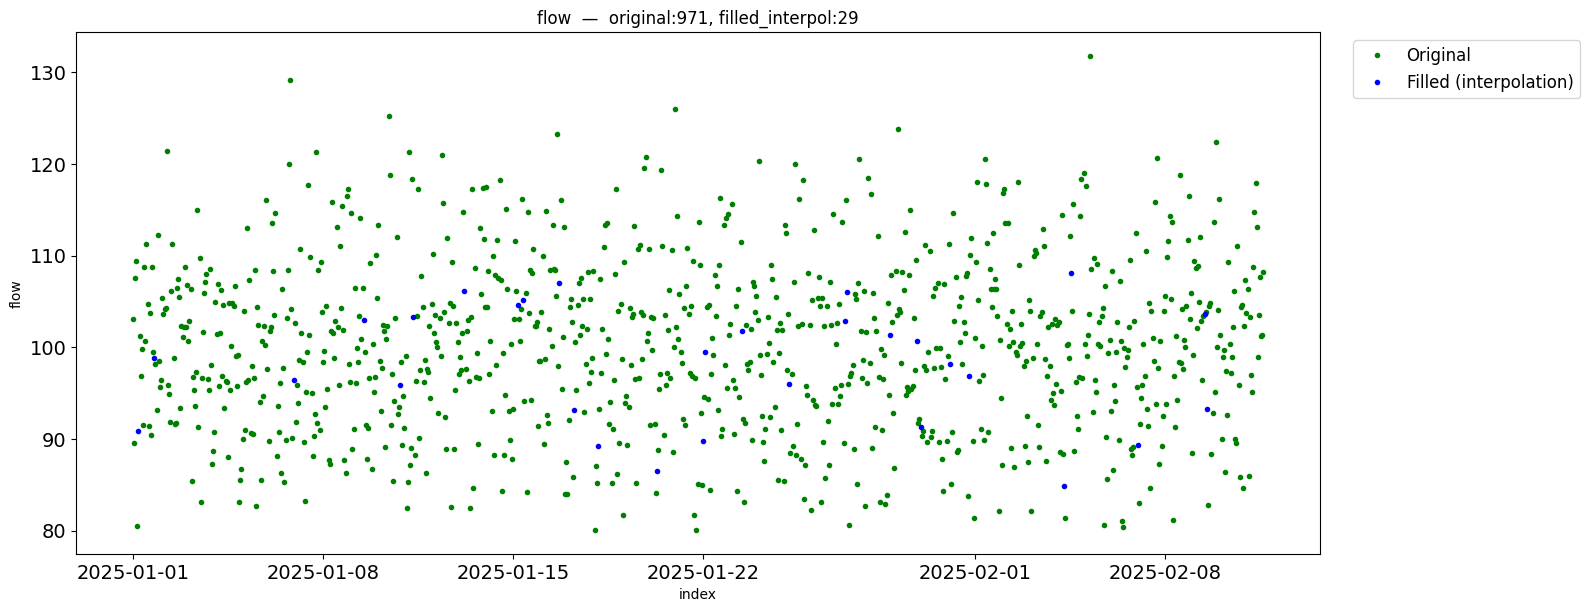

In [10]:
s.fill_missing_interpolation('flow', method='time', range_=5, plot=True)

In [ ]:
s.meta_filled

,flow
Datetime,
2025-01-01 00:00:00,original
2025-01-01 01:00:00,original
2025-01-01 02:00:00,original
2025-01-01 03:00:00,original
2025-01-01 04:00:00,original
...,...
2025-02-11 11:00:00,original
2025-02-11 12:00:00,original
2025-02-11 13:00:00,original


/home/saba/python_envs/env1/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


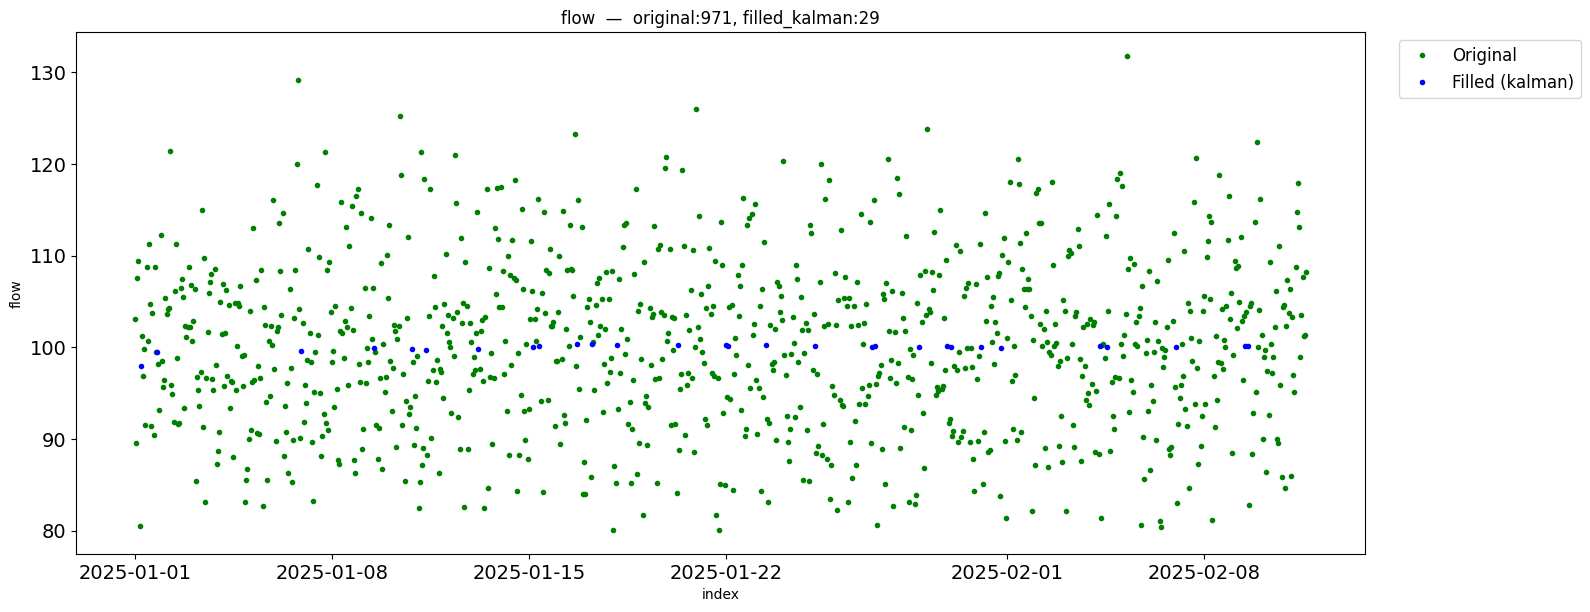

In [ ]:
s.fill_missing_kalman('flow', clear=True, plot=True)

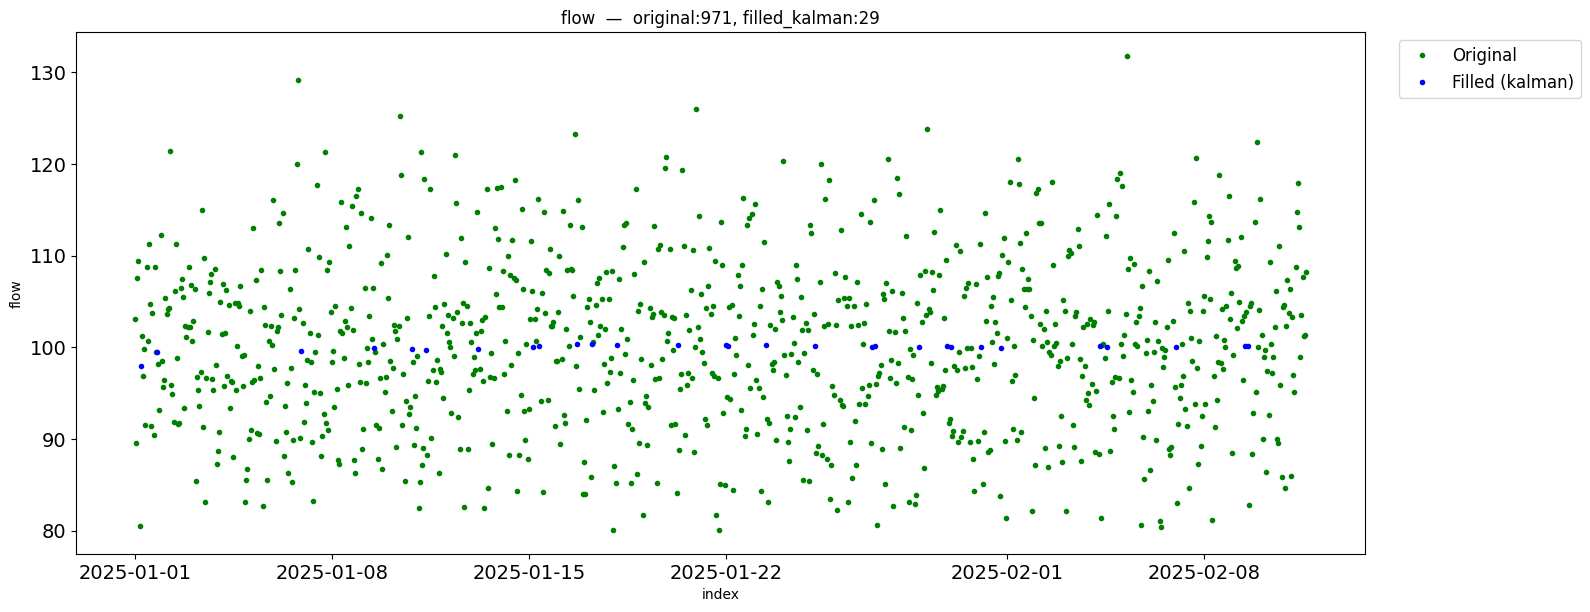

In [ ]:
s.fill_missing_arima('flow', plot=True)

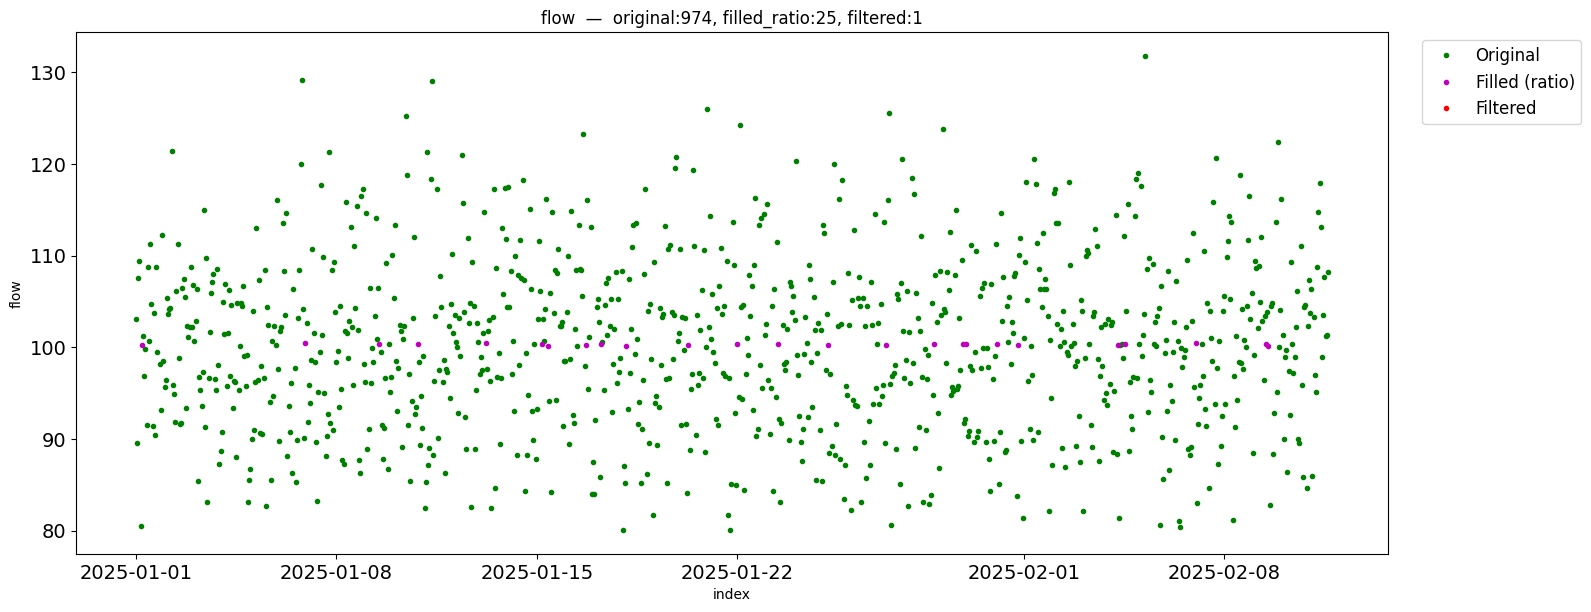

In [ ]:
s.fill_missing_ratio('flow', 'level', estimate_params=True, plot=True)

/tmp/ipykernel_9794/1690349566.py:1: RuntimeWarning: Rain/high events present; profile may not be representative.
  s.calc_daily_profile('flow', arange=(0,5), plot=True, clear=True)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Time of day', ylabel='flow'>)

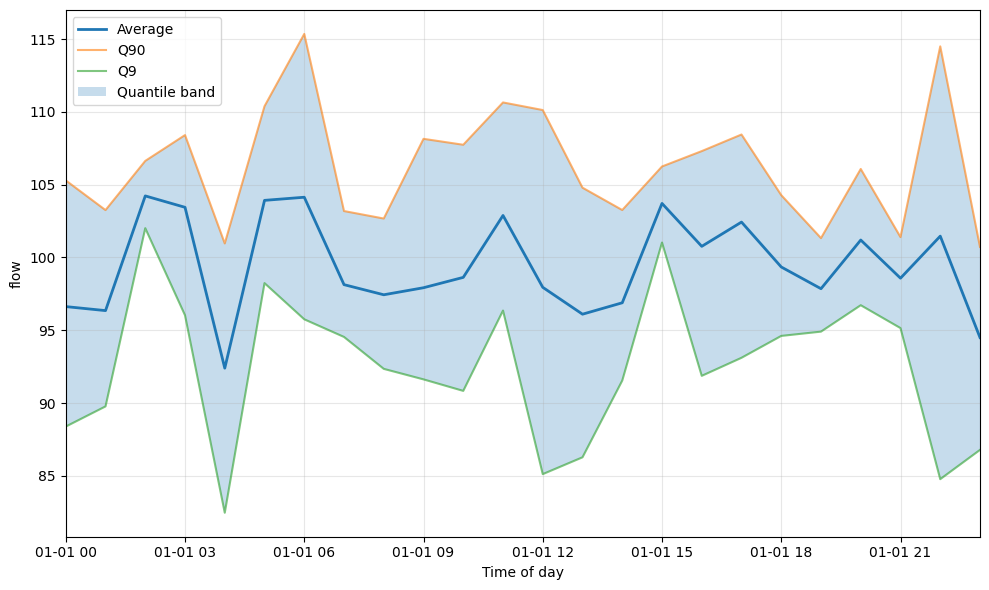

In [ ]:
s.calc_daily_profile('flow', arange=(0,5), plot=True, clear=True)

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:2541: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()


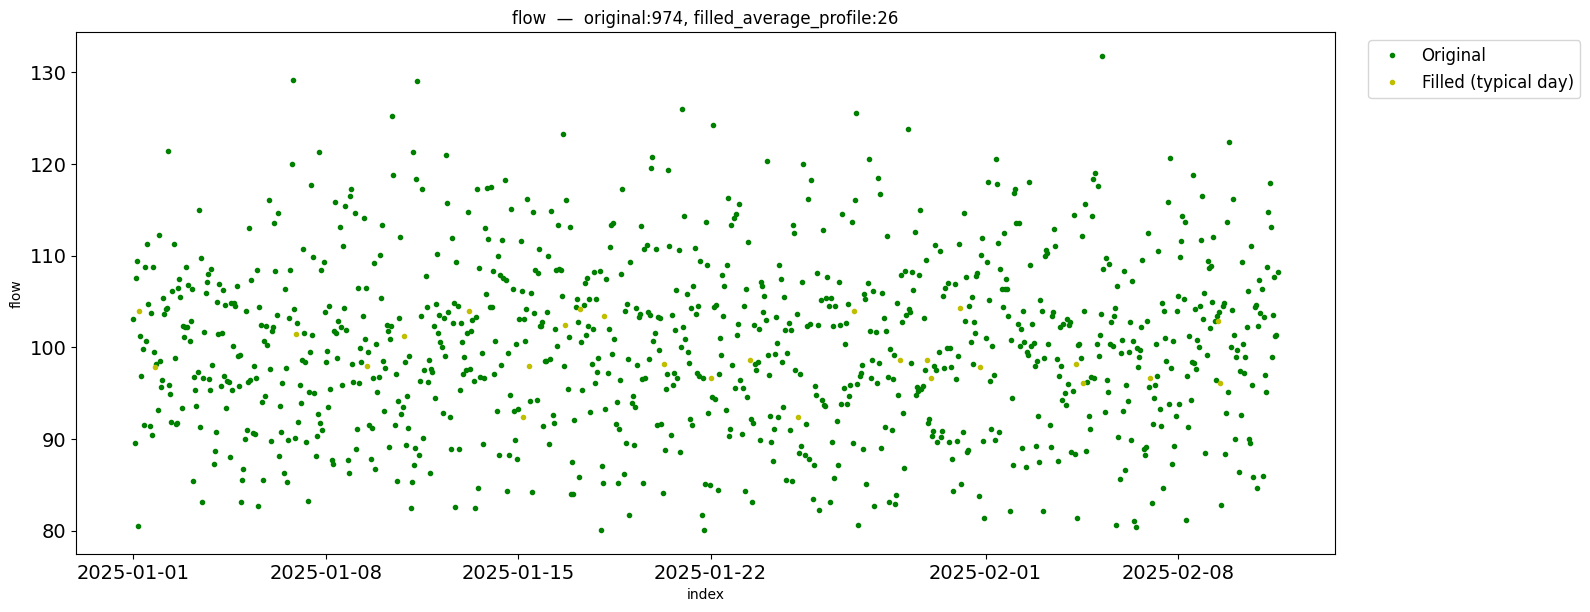

In [ ]:
s.fill_missing_standard('flow', plot=True)

In [ ]:
data_model = pd.DataFrame(np.zeros(1000), columns=['model'], index=s.data.index)
data_model['model'] = 30

data_model

,model
Datetime,
2025-01-01 00:00:00,30
2025-01-01 01:00:00,30
2025-01-01 02:00:00,30
2025-01-01 03:00:00,30
2025-01-01 04:00:00,30
...,...
2025-02-11 11:00:00,30
2025-02-11 12:00:00,30
2025-02-11 13:00:00,30


/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:3008: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()


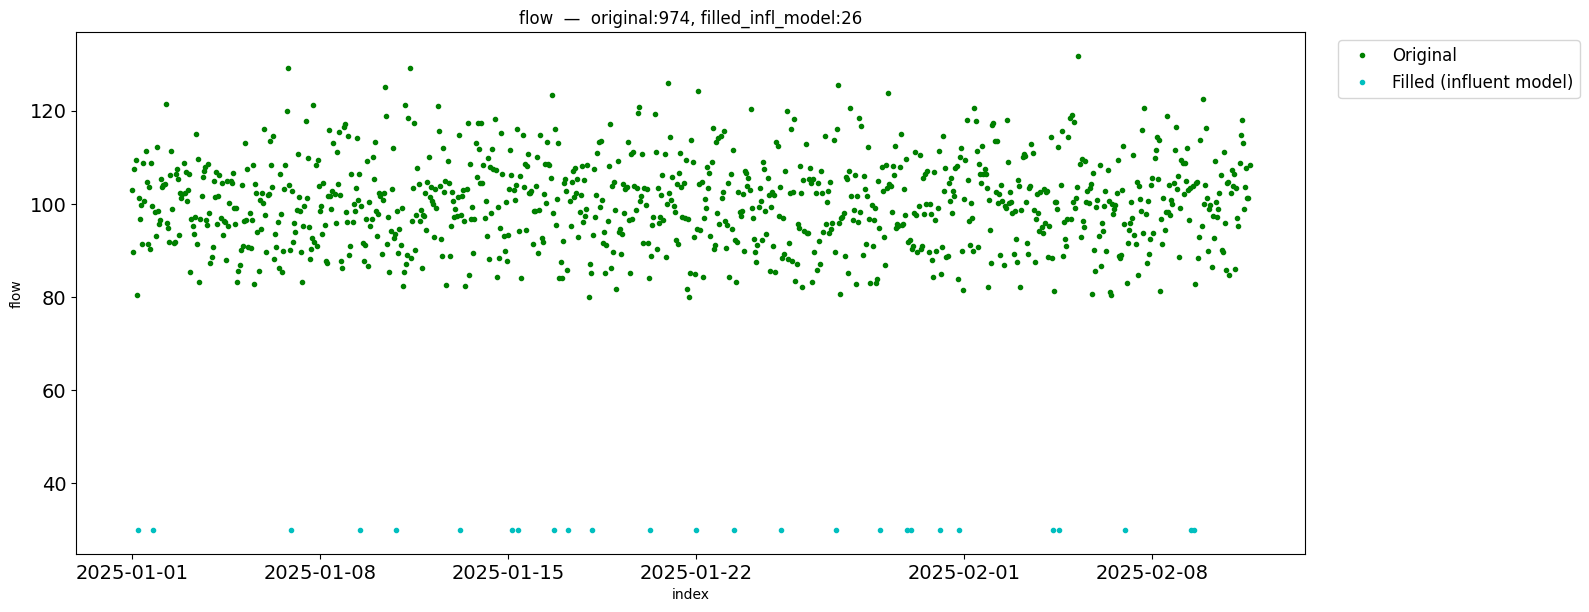

In [ ]:
s.fill_missing_model('flow', data_model, plot=True)

In [ ]:
start = s.data.index[100]
end = s.data.index[300]

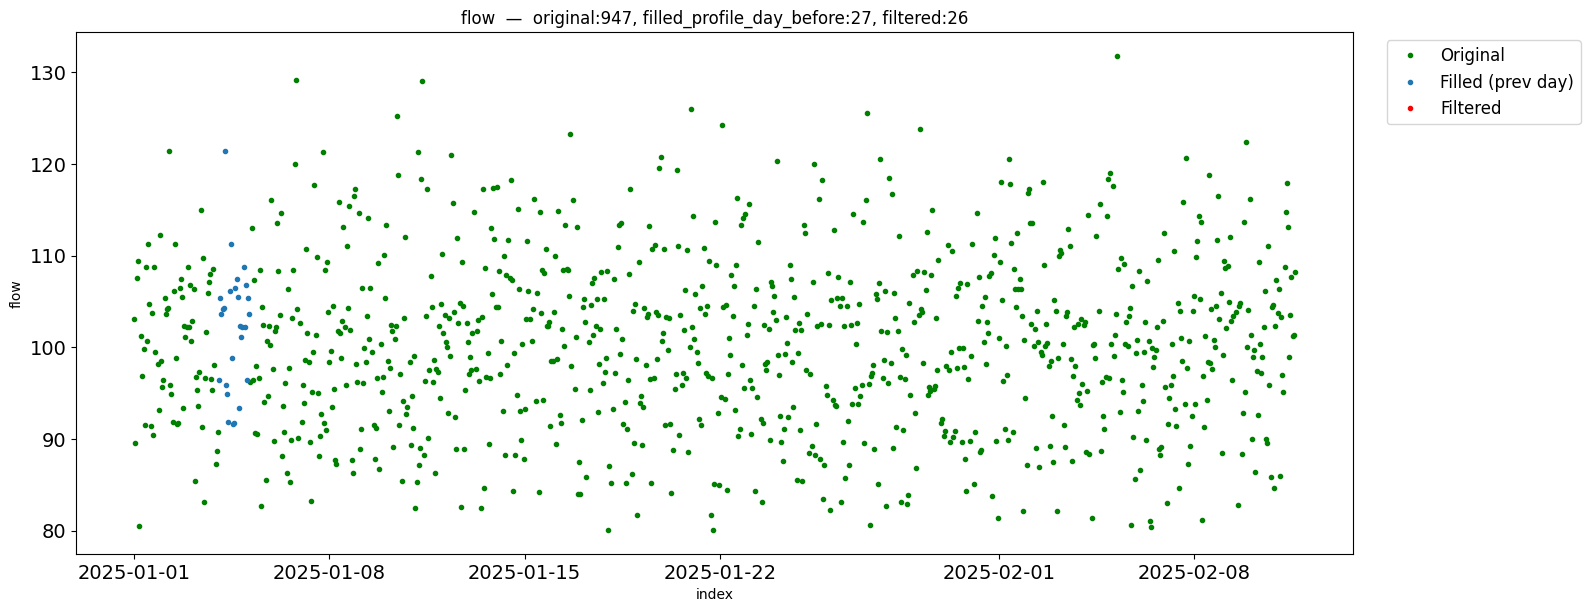

In [ ]:
s.fill_missing_daybefore('flow', arange=(start, end), plot=True)

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:2095: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/python_envs/env1/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


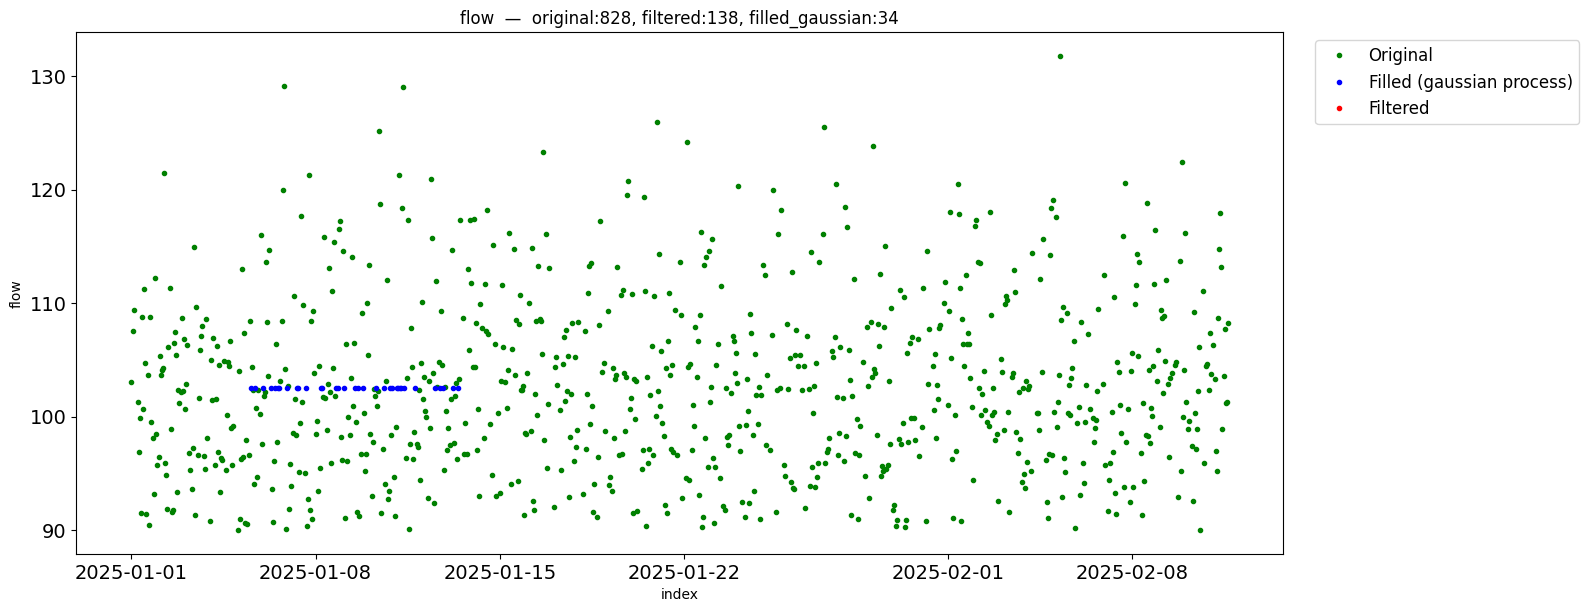

In [ ]:
s.fill_missing_gaussian('flow', arange=(start, end), plot=True)

In [ ]:
s.check_filling_error(5, 'flow', 'fill_missing_interpolation', test_data_range=(start,end), nr_small_gaps=2, max_size_small_gaps=5, range_=10)

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1294: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1182: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1294: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1182: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warn

method            fill_missing_interpolation
mean_error_pct                      8.779676
std_error_pct                       2.749258
n_success                                  5
n_attempts                                 5
success_rate                             1.0
dtype: object

In [ ]:
s.check_filling_error(2, 'flow', 'fill_missing_gaussian', test_data_range=(start,end), nr_small_gaps=3, nr_large_gaps=1, 
                       max_size_small_gaps=5, max_size_large_gaps=100)

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:2096: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/python_envs/env1/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:2096: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()


method            fill_missing_gaussian
mean_error_pct                 8.039031
std_error_pct                  1.116272
n_success                             2
n_attempts                            2
success_rate                        1.0
dtype: object

In [ ]:
s.check_filling_error(2, 'flow', 'fill_missing_kalman', test_data_range=(start,end), nr_small_gaps=2,  max_size_small_gaps=4)

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1760: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/python_envs/env1/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1760: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/python_envs/env1/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


method            fill_missing_kalman
mean_error_pct               7.271528
std_error_pct                0.222948
n_success                           2
n_attempts                          2
success_rate                      1.0
dtype: object

/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1294: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1182: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1294: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1182: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warn

,method,mean_error_pct,std_error_pct,n_success,n_attempts,success_rate
0,kalman_filter,6.555935,2.543631,2,2,1.0
1,gaussian_process,7.066073,6.821160,2,2,1.0
2,interpolation,12.144450,3.911310,2,2,1.0


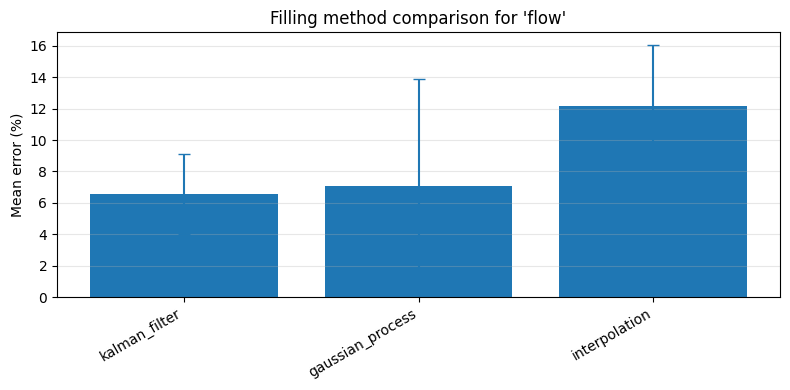

In [ ]:
s.compare_filling_methods('flow',
                          method_specs={
                              'interpolation': {'filling_function': 'fill_missing_interpolation', 'range_': 4},
                              'gaussian_process': {'filling_function': 'fill_missing_gaussian'},
                              'kalman_filter': {'filling_function': 'fill_missing_kalman'}
                          },
                          test_data_range=(start,end),
                          nr_iterations=2,
                          nr_small_gaps=2,  max_size_small_gaps=4,
                          plot=True
                          )

In [ ]:
df = make_test_dataframe(n=1000)
s = OnlineSensorBased(df)

s.fill_index((df.index.min(), df.index.max()))
s.drop_index_duplicates()

0 rows have been dropped as duplicates.


/tmp/ipykernel_9415/3718888463.py:4: RuntimeWarning: fill_index assumes equidistant sampling and inserts missing index values accordingly.
  s.fill_index((df.index.min(), df.index.max()))


In [ ]:
df2 = make_test_dataframe(n=1000, seed=20, start=pd.Timestamp("2025-01-01 00:30"))
l = LabExperimentBased(df2)

l.fill_index((df2.index.min(), df2.index.max()))
l.drop_index_duplicates()

0 rows of duplicate indices have been dropped.


/tmp/ipykernel_9415/4122121891.py:4: RuntimeWarning: fill_index assumes equidistant sampling and inserts missing index values accordingly.
  l.fill_index((df2.index.min(), df2.index.max()))


In [ ]:
l.data = l.data[::10]
l.data

,flow,level,rain
Datetime,,,
2025-01-01 00:30:00,96.403315,5.133075,0.0
2025-01-01 10:30:00,99.437081,4.812339,0.0
2025-01-01 20:30:00,85.726646,4.866615,0.0
2025-01-02 06:30:00,97.647205,5.374861,0.0
2025-01-02 16:30:00,104.760025,4.690032,0.0
...,...,...,...
2025-02-09 14:30:00,97.037551,4.797546,0.0
2025-02-10 00:30:00,90.556885,5.368578,0.0
2025-02-10 10:30:00,105.318779,5.223249,1.0


In [ ]:
l.validate_against('flow', s.data.flow, align_method='ffill')

ValidationMetrics(n=100, mae=11.690719498565768, rmse=15.03460192219663, mbe=0.013734247821120392, mape=11.9822815822517, r=-0.1501423840696937, r2=0.022542735494131418, ccc=-0.15011187842537804, slope=-0.14715276702689434, intercept=114.4355416832317)

In [ ]:
l.align_with_reference('flow', s.data.flow, method='ffill')

,lab,ref
Datetime,,
2025-01-01 00:30:00,96.403315,103.047171
2025-01-01 10:30:00,99.437081,108.793980
2025-01-01 20:30:00,85.726646,98.151376
2025-01-02 06:30:00,97.647205,121.416476
2025-01-02 16:30:00,104.760025,107.432542
...,...,...
2025-02-09 14:30:00,97.037551,82.765366
2025-02-10 00:30:00,90.556885,116.168744
2025-02-10 10:30:00,105.318779,97.172043


In [ ]:
l.fit_calibration('flow', s.data.flow)

{'slope': 0.10521408880392602,
 'intercept': 89.2289519326658,
 'r2': 0.00836867785772144}

In [ ]:
l.sensor_calibration(s.data.flow, 'flow')

{'slope': 0.10521408880392577,
 'intercept': 89.2289519326658,
 'r2': 0.00836867785772144}

In [1]:
import pandas as pd
import numpy as np

def make_test_dataframe(n: int = 48, freq: str = "h", seed: int = 42, start=pd.Timestamp("2025-01-01 00:00")) -> pd.DataFrame:
    """
    Create a synthetic sensor dataset for testing HydroData and DataProcessor methods.

    Parameters
    ----------
    n : int, default 48
        Number of time points.
    freq : str, default 'H'
        Frequency string for the DatetimeIndex (e.g., 'H', '15min').
    seed : int, default 42
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        A test DataFrame with columns ["flow", "level", "rain"] and a DatetimeIndex.
        Includes some NaNs, a duplicate timestamp, and an intentional gap.
    """
    rng = np.random.default_rng(seed)
    start = start
    idx = pd.date_range(start=start, periods=n, freq=freq)

    # Add a duplicate timestamp
    idx = idx.insert(10, idx[10])

    # Drop one index to create a gap
    idx = idx.delete(20)

    df = pd.DataFrame(
        {
            "flow": rng.normal(loc=100, scale=10, size=len(idx)),
            "level": rng.normal(loc=5, scale=0.5, size=len(idx)),
            "rain": rng.poisson(lam=0.2, size=len(idx)).astype(float),
        },
        index=idx,
    )

    # Introduce some NaNs
    df.iloc[5, 0] = np.nan  # missing flow
    df.iloc[15, 1] = np.nan  # missing level
    df.iloc[25, 2] = np.nan  # missing rain

    df.index.name = "Datetime"
    return df

## processing

In [2]:
df = make_test_dataframe(n=1000)
df.head()

,flow,level,rain
Datetime,,,
2025-01-01 00:00:00,103.047171,4.970359,0.0
2025-01-01 01:00:00,89.600159,4.635357,0.0
2025-01-01 02:00:00,107.504512,4.792763,0.0
2025-01-01 03:00:00,109.405647,5.316955,0.0
2025-01-01 04:00:00,80.489648,5.001497,0.0


In [3]:
from data_processor_refactor import DataProcessor

In [4]:
dp = DataProcessor(df)

[2025-10-17 12:14:13,627] INFO: Logger initialized for processor


In [9]:
dp.build_default_pipeline(columns=['flow'], small_gap_limit=2)

OnlineSensorBased object reset to original state.


In [6]:
print(dp.summary())

     enabled    kind             key                      method column  \
idx                                                                       
0       True  filter         tag_nan                     tag_nan   flow   
1       True  filter  moving_average       moving_average_filter   flow   
2       True  filter          zscore               zscore_filter   flow   
3       True  filter             iqr                  iqr_filter   flow   
4       True    fill   interpolation  fill_missing_interpolation   flow   

                                                params  
idx                                                     
0                     {'arange': None, 'clear': False}  
1    {'window': 7, 'cutoff_frac': 0.25, 'arange': N...  
2    {'k': 2.71, 'arange': None, 'final': False, 'i...  
3    {'k': 1.5, 'arange': None, 'final': False, 'in...  
4    {'range_': 2, 'arange': None, 'method': 'time'...  


/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1352: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
[2025-10-17 12:17:02,835] INFO: Data processing run is finished!


1 values detected and tagged as filtered by function NaN tagging
7 values detected and tagged as filtered by function moving average filter (kind=mean)
6 values detected and tagged as filtered by function z-score filter (standard)
10 values detected and tagged as filtered by function IQR filter (k=1.5)


[(0, 'tag_nan', {'arange': None, 'clear': False}, None),
 (1,
  'moving_average_filter',
  {'window': 7,
   'cutoff_frac': 0.25,
   'arange': None,
   'clear': False,
   'final': False,
   'inplace': False,
   'plot': False},
  None),
 (2,
  'zscore_filter',
  {'k': 2.71, 'arange': None, 'final': False, 'inplace': False, 'plot': False},
  None),
 (3,
  'iqr_filter',
  {'k': 1.5, 'arange': None, 'final': False, 'inplace': False, 'plot': False},
  None),
 (4,
  'fill_missing_interpolation',
  {'range_': 2,
   'arange': None,
   'method': 'time',
   'clear': False,
   'plot': True},
  None)]

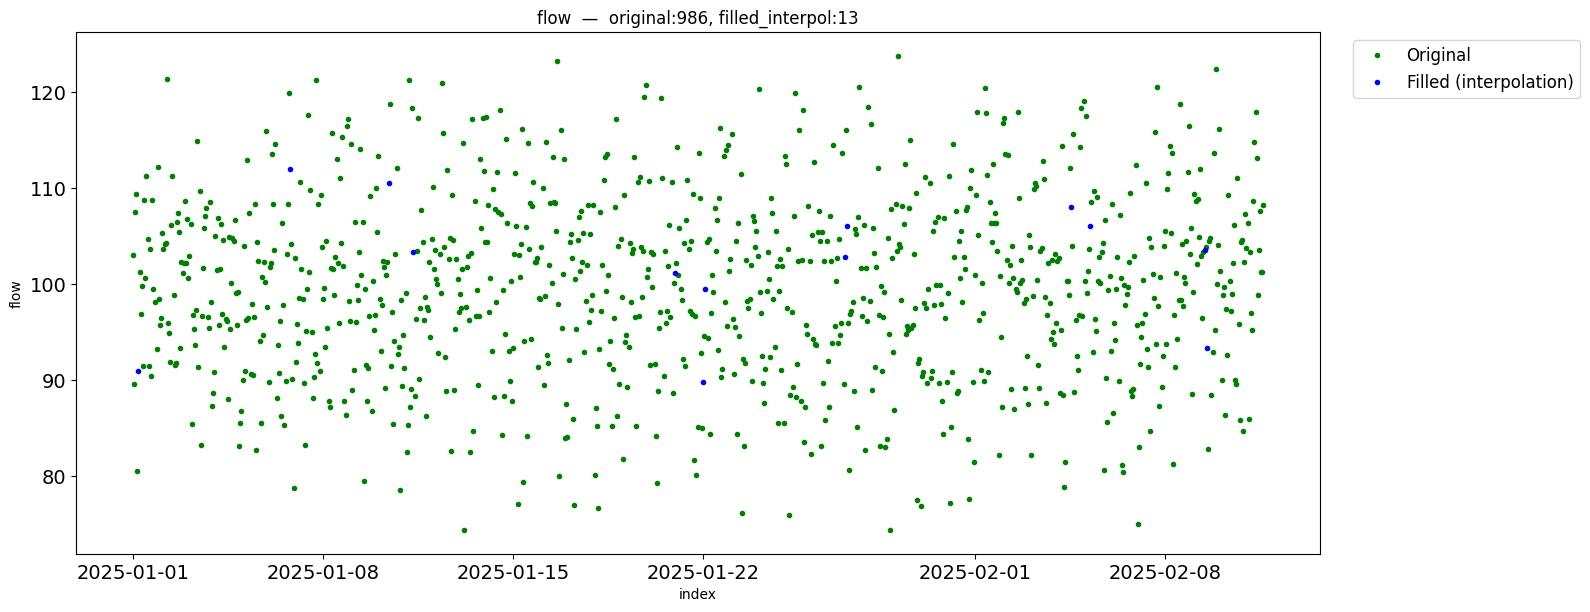

In [10]:
dp.run()

In [12]:
dp.get_logs(as_text=False)

['[2025-10-17 12:14:13,627] INFO: Logger initialized for processor',
 '[2025-10-17 12:14:27,751] INFO: Data processing run is finished!',
 '[2025-10-17 12:17:02,835] INFO: Data processing run is finished!']

In [8]:
dp.osb.meta_valid[dp.osb.meta_valid.flow == 'filtered']

,flow
Datetime,
2025-01-01 05:00:00,filtered
2025-01-06 19:00:00,filtered
2025-01-10 10:00:00,filtered
2025-01-11 08:00:00,filtered
2025-01-20 23:00:00,filtered
2025-01-22 00:00:00,filtered
2025-01-22 02:00:00,filtered
2025-01-27 05:00:00,filtered
2025-01-27 07:00:00,filtered


In [18]:
dp.osb.meta_valid[dp.osb.meta_filled.flow == 'filled_interpol']

,flow
Datetime,


In [ ]:

grid = {"k": [1.0, 1.5, 2.0, 2.5]}
best = dp.brute_force_filter_params("flow", key="iqr", param_grid=grid, base_kwargs={"arange": None})
print(best)

42 values detected and tagged as filtered by function IQR filter (k=1.0)
0 values detected and tagged as filtered by function IQR filter (k=1.5)
0 values detected and tagged as filtered by function IQR filter (k=2.0)
0 values detected and tagged as filtered by function IQR filter (k=2.5)
{'best_params': {'k': 1.0}, 'score': 1.0}


In [14]:
dp.clear_pipeline()

                           flow     level  rain
Datetime                                       
2025-01-01 00:00:00  103.047171  4.970359   0.0
2025-01-01 01:00:00   89.600159  4.635357   0.0
2025-01-01 02:00:00  107.504512  4.792763   0.0
2025-01-01 03:00:00  109.405647  5.316955   0.0
2025-01-01 04:00:00   80.489648  5.001497   0.0
...                         ...       ...   ...
2025-02-11 11:00:00  103.527202  5.196005   0.0
2025-02-11 12:00:00  107.668229  5.151919   1.0
2025-02-11 13:00:00  101.211779  4.954230   1.0
2025-02-11 14:00:00  101.307642  4.734589   0.0
2025-02-11 15:00:00  108.237531  6.107076   0.0

[999 rows x 3 columns]
OnlineSensorBased object reset to original state.


In [15]:

variable = 'flow'
dp.add_step('filter', 'tag_nan', variable, arange=None)
dp.add_step('filter', 'moving_average', variable, window=7, cutoff_frac=0.25)
dp.add_step('filter', 'iqr', variable, k=1.5)
dp.add_step('fill', 'interpolation', variable, range_=5, plot=True)
dp.add_step('fill', 'kalman', variable, plot=True)

1 values detected and tagged as filtered by function NaN tagging
7 values detected and tagged as filtered by function moving average filter (kind=mean)
10 values detected and tagged as filtered by function IQR filter (k=1.5)


/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1352: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()


[(0, 'tag_nan', {'arange': None}, None),
 (1, 'moving_average_filter', {'window': 7, 'cutoff_frac': 0.25}, None),
 (2, 'iqr_filter', {'k': 1.5}, None),
 (3, 'fill_missing_interpolation', {'range_': 5, 'plot': True}, None),
 (4, 'fill_missing_kalman', {'plot': True}, None)]

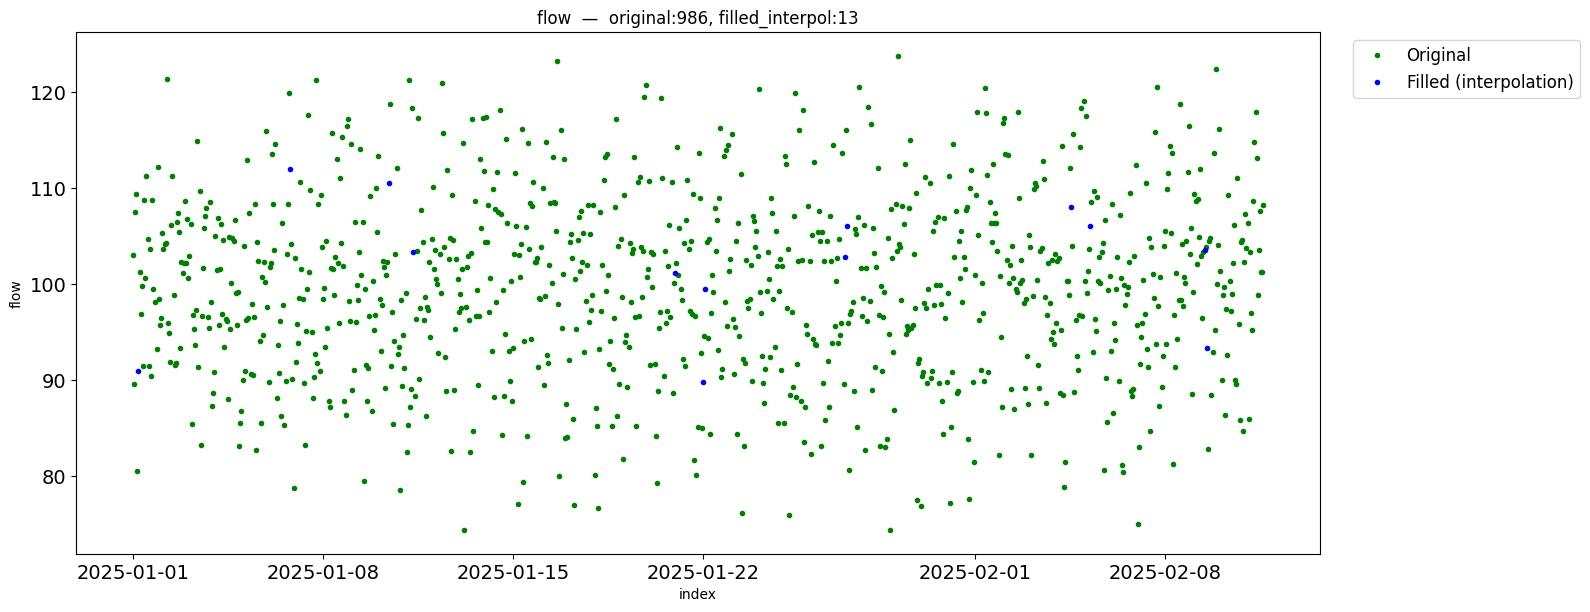

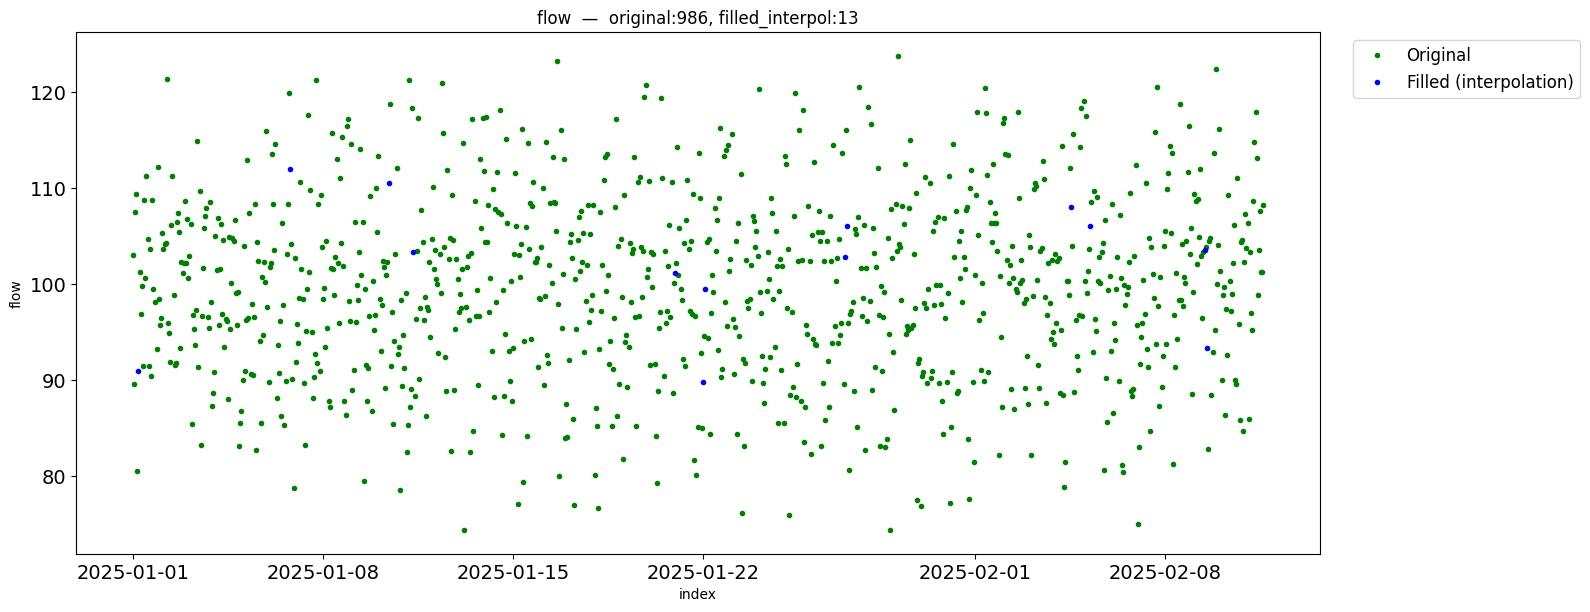

In [16]:
dp.run()

In [7]:
dp.osb.meta_valid[dp.osb.meta_valid.flow == 'filtered']

,flow
Datetime,
2025-01-01 05:00:00,filtered
2025-01-11 08:00:00,filtered
2025-01-22 00:00:00,filtered
2025-01-22 02:00:00,filtered
2025-01-27 05:00:00,filtered
2025-01-27 07:00:00,filtered
2025-02-04 13:00:00,filtered
2025-02-09 13:00:00,filtered


In [ ]:
fill_grid = {"range_": [3, 5, 7, 9]}
start = dp.osb.data.index.min()
end = dp.osb.data.index.max()


best_fill = dp.brute_force_fill_params_with_reliability(
    column="flow",
    key="interpolation",
    param_grid=fill_grid,
    test_data_range=(start, end),
    nr_iterations=2,
    nr_small_gaps=2, max_size_small_gaps=5
)
print(best_fill)

{'best_params': {}, 'score': None}


/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1295: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1183: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1295: UserWarning: When using filling functions, start with small gaps and progressively move to larger gaps. This improves algorithm reliability. This notice is shown only once.
  self._filling_warning()
/home/saba/Desktop/wwdata_refactor/Class_OnlineSensorBased.py:1183: UserWarning: Data points obtained during rain/high events will be replaced. Ensure the chosen method is appropriate for gaps during rain events.
  self._rain_warn

In [9]:
dp.export_data('/home/saba/Desktop/')

✅ Export complete: /home/saba/Desktop/processed_data_20251017_111604.zip


'/home/saba/Desktop/processed_data_20251017_111604.zip'